In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 7.5 MB/s eta 0:00:00


## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

path = "/content/drive/MyDrive/Colab Notebooks/deteksi Plat"

## Persiapkan Gambar Nomor Plat Mobil dan Filter Haar

In [ ]:
import cv2
import matplotlib.pyplot as plt

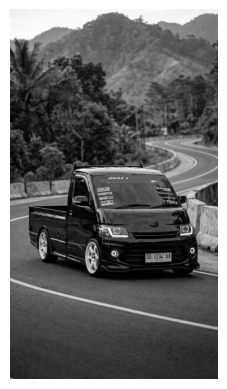

In [ ]:
car_plate = os.path.join(path, 'data/pickup.jpg')
img = cv2.imread(car_plate, 0)

plt.axis('off')
plt.imshow(img, cmap='gray')

In [ ]:
img2 = img.copy()

print(img2.shape)

# classifier plat nomor
plat_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)

# deteksi plat
deteksi_plate = plat_cascade.detectMultiScale(
    img2,
    scaleFactor=1.03,
    minNeighbors=8,
    minSize=(80,20),
    maxSize=(300,100)
)

(1308, 736)


## Deteksi bagian nomor plat dari gambar mobil

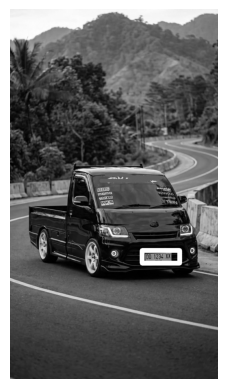

In [ ]:
# berikan kotak pembatas pada nomor plat yang terdeteksi

for(x,y,w,h) in deteksi_plate:
    cv2.rectangle(img2, (x,y), (x+w, y+h), (255), 15)

plt.axis('off')
plt.imshow(img2, cmap='gray')

## Blur atau kaburkan nomor plat yang telah terdeteksi

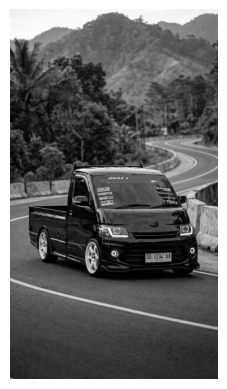

In [ ]:
# Kaburkan atau blur nomor plat
img3 = img.copy()

deteksi_plate = plat_cascade.detectMultiScale(img3,
                                             minNeighbors=15)

for(x,y,w,h) in deteksi_plate:
    target = img3[y:y+h, x:x+w]
    target = cv2.GaussianBlur(target, (101,101), 0)
    img3[y:y+h, x:x+w] = target

plt.axis('off')
plt.imshow(img3, cmap='gray')

## Ekstrak Nomor Plat dari gambar plat yang telah terdeteksi

(1308, 736)


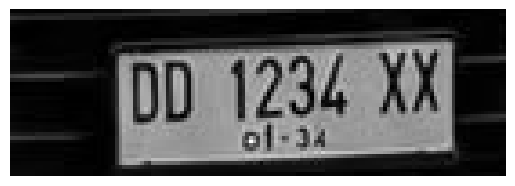

In [ ]:
#duplikasikan kembali gambar input
img4 = img.copy()

print(img4.shape)

#lakukan detekasi dengan plat_cascade yang sudah ada
deteksi_plate = plat_cascade.detectMultiScale(
    img2,
    scaleFactor=1.03,
    minNeighbors=8,
    minSize=(80,20),
    maxSize=(300,100)
)

# Ambil potongan plat dari gambar
cropped_plate = []
for(x,y,w,h) in deteksi_plate:
    cropped_plate.append(img4[y:y+h, x:x+w])

# Lihat potongan plat
for i, plate in enumerate(cropped_plate):
    plt.subplot(1, len(cropped_plate), i + 1)
    plt.axis('off')
    plt.imshow(plate, cmap='gray')

plt.show()

In [ ]:
import easyocr
reader = easyocr.Reader(['en'])

for plate in cropped_plate:

    th, plate = cv2.threshold(plate, 100, 255, cv2.THRESH_BINARY)
    plate = cv2.blur(plate, (2,2))

    result = reader.readtext(plate)

    for (bbox, text, prob) in result:
       #if prob > 0.70:
            #(top_left, top_right, bottom_right, bottom_left) = bbox
            print(f'Text: {text}, Probability: {prob}')

Text: 1234 XY, Probability: 0.27257151429161486
